Total Earnings: $30600
Average Monthly Earnings: $2550.00
Growth Rate: 55.00%


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


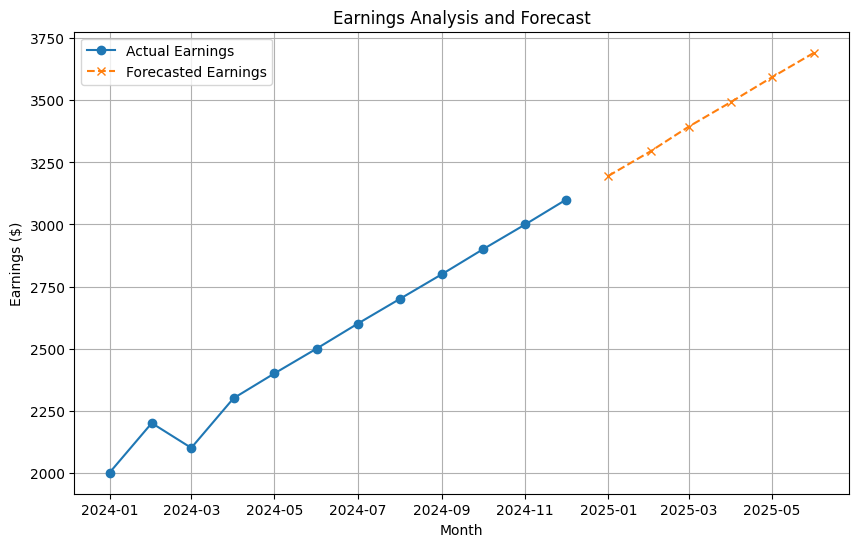


--- Summary ---
Forecasted Earnings (next 6 months):
2025-01-01    3195.463589
2025-02-01    3294.765678
2025-03-01    3394.067768
2025-04-01    3493.369858
2025-05-01    3592.671948
2025-06-01    3691.974037
Freq: MS, dtype: float64


In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Sample dataset
data = {
    'Month': ["Jan 2024", "Feb 2024", "Mar 2024", "Apr 2024", "May 2024", "Jun 2024", "Jul 2024", "Aug 2024", "Sep 2024", "Oct 2024", "Nov 2024", "Dec 2024"],
    'Earnings': [2000, 2200, 2100, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100]
}

# Creating DataFrame
df = pd.DataFrame(data)

# Convert Month to datetime format
df['Month'] = pd.to_datetime(df['Month'], format="%b %Y")

# Set Month as the index
df.set_index('Month', inplace=True)

# Calculate basic financial metrics
total_earnings = df['Earnings'].sum()
average_earnings = df['Earnings'].mean()
growth_rate = ((df['Earnings'].iloc[-1] - df['Earnings'].iloc[0]) / df['Earnings'].iloc[0]) * 100

# Display metrics
print(f"Total Earnings: ${total_earnings}")
print(f"Average Monthly Earnings: ${average_earnings:.2f}")
print(f"Growth Rate: {growth_rate:.2f}%")

# Forecasting future earnings
# Using Exponential Smoothing
model = ExponentialSmoothing(df['Earnings'], trend='add', seasonal=None, seasonal_periods=None)
fit = model.fit()
forecast = fit.forecast(steps=6)  # Forecast for the next 6 months

# Generate a forecast index
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=len(forecast), freq='MS')
forecast_df = pd.DataFrame({'Earnings': forecast}, index=forecast_index)

# Combine the actual and forecasted data
df_combined = pd.concat([df, forecast_df.rename(columns={'Earnings': 'Forecast'})], axis=1)

# Save the combined data to CSV
df_combined.to_csv("financial_analysis_forecast.csv")

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Earnings'], label='Actual Earnings', marker='o')
plt.plot(forecast_df.index, forecast_df['Earnings'], label='Forecasted Earnings', linestyle='--', marker='x')
plt.title('Earnings Analysis and Forecast')
plt.xlabel('Month')
plt.ylabel('Earnings ($)')
plt.legend()
plt.grid()
plt.show()

# Summary
print("\n--- Summary ---")
print(f"Forecasted Earnings (next 6 months):\n{forecast}")
